## Sentiment Analysis 

In [2]:
import pandas as pd
import re
from collections import Counter

## Function to import the dict

In [16]:
def load_filtered_liwc_dictionary(filepath, allowed_ids):
    with open(filepath, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    category_map = {}
    liwc_dict = {}
    percent_count = 0

    for line in lines:
        line = line.strip()
        if not line:
            continue
        if line == '%':
            percent_count += 1
            continue

        parts = line.split()

        # category 
        if percent_count == 1:
            if len(parts) >= 2:
                cat_id = parts[0]
                cat_name = parts[1]
                if cat_id in allowed_ids:
                    category_map[cat_id] = cat_name

        # word finding 
        elif percent_count == 2:
            word = parts[0]
            cat_ids = parts[1:]
            # restriction for further processing
            filtered_ids = [cid for cid in cat_ids if cid in allowed_ids]
            categories = [category_map.get(cid) for cid in filtered_ids if cid in category_map]
            if categories:
                liwc_dict[word] = categories

    return liwc_dict


When comparing the studies in our literature review, I decided to shrink the different LIWC Categories to seven most relevant. 

01	Pronoun, 13	Positiveemotion, 16	Negativeemotion, 35	Family, 50	Achieve, 58	Relig, 15	Optimism.

In [17]:
allowed_ids = {'01', '13', '15', '16', '35', '50', '58'} # allowed LIWC categories as defined in the above function 
liwc_dict = load_filtered_liwc_dictionary("../data/LIWC_German.txt", allowed_ids) # importing the 2001 dict 

### After converting the dictionary, the following includes a function to use the dictionary on datasets

In [14]:
def analyze_text_liwc(text, liwc_dict):
    if pd.isnull(text):
        return {}
    
    tokens = re.findall(r'\b\w+\b', text.lower())
    token_count = len(tokens)
    if token_count == 0:
        return {}

    category_counts = {}

    for token in tokens:
        for word, categories in liwc_dict.items():
            if word.endswith("*"):
                if token.startswith(word[:-1]):
                    for cat in categories:
                        category_counts[cat] = category_counts.get(cat, 0) + 1
            elif token == word:
                for cat in categories:
                    category_counts[cat] = category_counts.get(cat, 0) + 1

    # change to percent values
    category_percentages = {cat: (count / token_count) * 100 for cat, count in category_counts.items()}
    return category_percentages


In [18]:
liwc_dict = load_filtered_liwc_dictionary("../data/LIWC_German.txt", allowed_ids)

For the analysis, our study has several speech datasets:
 
 - original speeches from the bundestagmine
 
 Generated speeches:

 - Llama2 speeches with RAG implementions
 - Llama 3 speeches with RAG and fine tuning 
 - GPT generated speeches 

 For all of this speeches, we decided to perform a LIWC Analysis  

### 1 Original speeches 

In [3]:
data_orig = pd.read_csv("../data/data_speeches_original_cleaned.csv")

In [9]:
data_orig

,speech_text,legislative_period,protocol_nr,agenda_item_number,party,agenda_item_title,date,full_name,cleaned_text,word_count,liwc_counts
0,Sehr geehrte Frau Präsidentin! Werte Kolleginn...,20,79,12,Union,EU-Richtlinie Umweltauswirkungen Kunststoffpro...,2023-01-19,Björn Simon,Auch von meiner Seite aus einen herzlichen Glü...,789,"{'Positiveemotion': 5.6878306878306875, 'Negat..."
1,Hochgeschätzter Herr Präsident! Kolleginnen un...,19,23,6,Union,Verkehr und digitale Infrastruktur,2018-03-22,Andreas Scheuer,Luftqualität ist Lebensqualität; aber Lebensqu...,1292,"{'Achieve': 4.8, 'Positiveemotion': 4.47999999..."
2,Frau Präsidentin! Verehrte Kolleginnen und Kol...,20,18,8,Union,Aktuelle Stunde - Bundeswehreinsätze in Mali b...,2022-02-18,Reinhard Brandl,Die Ampelkoalition kann jetzt nichts für die S...,741,"{'Positiveemotion': 4.137931034482759, 'Achiev..."
3,Frau Präsidentin! Liebe Kolleginnen und Kolleg...,20,21,4,Union,Meinungsfreiheit in Sozialen Medien,2022-03-17,Marc Henrichmann,Das vierte Wort im Antrag der AfD ist „Russlan...,936,"{'Positiveemotion': 3.0303030303030303, 'Achie..."
4,Herr Präsident! Meine sehr verehrten Damen und...,19,164,3,Union,Bundeswehreinsatz EUTM Mali,2020-05-29,Johann David Wadephul,Die Lage im Sahel ist kritisch. Sie ist sogar ...,1011,"{'Negativeemotion': 2.6052104208416833, 'Achie..."
...,...,...,...,...,...,...,...,...,...,...,...
21703,Frau Präsidentin! Liebe Kolleginnen und Kolleg...,19,209,9,LINKE,Gentechnik-Standort Deutschland,2021-02-11,Kirsten Tackmann,Thema dieser Debatte ist mal wieder Gentechnik...,416,"{'Positiveemotion': 4.411764705882353, 'Achiev..."
21704,Vielen Dank. – Frau Präsidentin! Liebe Kollegi...,19,223,7,LINKE,Bundeswehreinsatz EU NAVFOR Somalia ATALANTA,2021-04-21,Kathrin Vogler,Vielen Dank. Die Bundesregierung will den Bund...,408,"{'Positiveemotion': 3.194103194103194, 'Negati..."
21705,Frau Präsidentin! Frau Ministerin! Liebe Kolle...,19,185,3,LINKE,Aktuelle Stunde - Reform der Gemeinsamen Agrar...,2020-10-28,Kirsten Tackmann,Frau Ministerin! In dieser Aktuellen Stunde ge...,696,"{'Family': 0.7267441860465116, 'Positiveemotio..."
21706,Sehr geehrter Herr Präsident! Liebe Kolleginne...,20,85,13,LINKE,Zentralisierung der Rechtsdienstleistungsaufsicht,2023-02-09,Clara Bünger,Und – die frohe Botschaft kann ich schon mal s...,403,"{'Positiveemotion': 4.335260115606936, 'Optimi..."


In [15]:
data_orig["liwc_counts"] = data_orig["cleaned_text"].apply(lambda x: analyze_text_liwc(x, liwc_dict))

In [16]:
data_orig.to_csv("../data/data_speeches_original_liwc_added.csv", index=False)

In [19]:
data_orig = pd.read_csv("../data/data_speeches_original_liwc_added.csv", sep=",")

In [23]:
data_orig_fine = data_orig["liwc_counts"].apply(pd.Series).fillna(0)

In [24]:
data_orig_fine.head()

,0
0,"{'Positiveemotion': 5.6878306878306875, 'Negat..."
1,"{'Achieve': 4.8, 'Positiveemotion': 4.47999999..."
2,"{'Positiveemotion': 4.137931034482759, 'Achiev..."
3,"{'Positiveemotion': 3.0303030303030303, 'Achie..."
4,"{'Negativeemotion': 2.6052104208416833, 'Achie..."


In [ ]:
import ast
data_orig['liwc_counts'] = data_orig['liwc_counts'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

liwc = pd.json_normalize(data_orig['liwc_counts']).fillna(0)
final_df_1 = pd.concat([data_orig[['party']].reset_index(drop=True),
                        liwc.reset_index(drop=True)], axis=1)

final_df_1 = final_df_1.round(2).drop(columns=['origin','Origin'], errors='ignore')
print(final_df_1.head())


   party  Positiveemotion  Negativeemotion  Achieve  Optimism  Relig  Family
0  Union             5.69             1.59     6.88      1.85   0.53    0.00
1  Union             4.48             0.56     4.80      1.52   0.72    0.24
2  Union             4.14             1.38     5.66      1.24   1.38    0.14
3  Union             3.03             2.81     2.71      0.97   1.19    0.87
4  Union             4.41             2.61     5.41      2.20   0.70    0.10


In [26]:
final_df_1

,party,Positiveemotion,Negativeemotion,Achieve,Optimism,Relig,Family
0,Union,5.69,1.59,6.88,1.85,0.53,0.00
1,Union,4.48,0.56,4.80,1.52,0.72,0.24
2,Union,4.14,1.38,5.66,1.24,1.38,0.14
3,Union,3.03,2.81,2.71,0.97,1.19,0.87
4,Union,4.41,2.61,5.41,2.20,0.70,0.10
...,...,...,...,...,...,...,...
21703,LINKE,4.41,0.74,3.68,2.21,0.98,0.25
21704,LINKE,3.19,1.97,5.16,1.23,1.72,0.00
21705,LINKE,2.76,2.03,3.49,1.02,0.15,0.73
21706,LINKE,4.34,1.16,6.65,2.89,0.29,0.00


In [27]:
final_df_1 = final_df_1.assign(Origin = ['original'] * len(final_df_1))
final_df_1

,party,Positiveemotion,Negativeemotion,Achieve,Optimism,Relig,Family,Origin
0,Union,5.69,1.59,6.88,1.85,0.53,0.00,original
1,Union,4.48,0.56,4.80,1.52,0.72,0.24,original
2,Union,4.14,1.38,5.66,1.24,1.38,0.14,original
3,Union,3.03,2.81,2.71,0.97,1.19,0.87,original
4,Union,4.41,2.61,5.41,2.20,0.70,0.10,original
...,...,...,...,...,...,...,...,...
21703,LINKE,4.41,0.74,3.68,2.21,0.98,0.25,original
21704,LINKE,3.19,1.97,5.16,1.23,1.72,0.00,original
21705,LINKE,2.76,2.03,3.49,1.02,0.15,0.73,original
21706,LINKE,4.34,1.16,6.65,2.89,0.29,0.00,original


In [28]:
# grouping by party and calculating mean values
final_df_1_grouped = final_df_1.groupby('party').mean().reset_index()


In [29]:
final_df_1_grouped
final_df_1_grouped = final_df_1_grouped.assign(Origin = ['original'] * len(final_df_1_grouped))

In [30]:
final_df_1_grouped

,party,Positiveemotion,Negativeemotion,Achieve,Optimism,Relig,Family,Origin
0,AfD,3.482855,1.911617,4.373549,1.146382,0.978057,0.499613,original
1,FDP,4.226255,1.633027,4.760857,1.327966,0.896401,0.430879,original
2,GRÜNE,4.127623,1.685826,4.722595,1.243787,0.839005,0.437377,original
3,LINKE,3.597786,1.975050,4.568386,1.177847,0.857593,0.434176,original
4,SPD,4.446081,1.438803,4.655086,1.315550,0.787026,0.420135,original
5,Union,4.146150,1.448043,4.576855,1.310323,0.922836,0.439276,original


### Dataset 2: Original party, but restricted to topics that we used in our prompts


In [31]:
def classify_topic_from_agenda(title):
    if pd.isna(title):
        return "Sonstiges"

    title = str(title).lower()

    # 1
    if "mindestlohn" in title or "lohnerhöhung" in title or "arbeitslohn" in title:
        return "Mindestlohn"

    # 2
    elif "kosovo" in title or "kfor" in title or "bundeswehreinsatz im kosovo" in title or "einsatz der bundeswehr im kosovo" in title:
        return "Kosovo"

    # 3
    elif any(term in title for term in [
        "corona", "covid", "pandemie", "wirtschaftshilfe",
        "wirtschaftsstabilisierungsfonds", "coronahilfen",
        "pandemiehilfe",
    ]):
        return "Pandemiehilfen"

    # 4
    elif any(term in title for term in [
        "gas", "gaspreis", "energiepreis", "energiepreise",
        "gasversorgung", "gasmarkt", "energiekrise",
        "preisdeckel", "gaspreisbremse"
    ]):
        return "Gaspreise"

    else:
        return "Sonstiges"


In [32]:
data_orig["topic_for_RGA"] = data_orig["agenda_item_title"].apply(classify_topic_from_agenda)

In [33]:
dataframe_2 = data_orig[data_orig["topic_for_RGA"] != "Sonstiges"]
dataframe_2 = dataframe_2.drop("liwc_counts", axis=1, errors='ignore')

In [34]:
dataframe_2["liwc_counts"] = dataframe_2["cleaned_text"].apply(lambda x: analyze_text_liwc(x, liwc_dict))

In [35]:
df2_alpha = dataframe_2["liwc_counts"].apply(pd.Series).fillna(0)

In [36]:
df2_beta = pd.concat([dataframe_2[["party", "topic_for_RGA"]], df2_alpha], axis=1)
df2_beta = df2_beta.round(2)

In [37]:
df2_beta

,party,topic_for_RGA,Achieve,Negativeemotion,Positiveemotion,Optimism,Relig,Family
25,Union,Pandemiehilfen,3.30,0.66,3.43,1.19,0.26,0.66
26,Union,Pandemiehilfen,5.17,2.49,5.36,2.11,1.53,0.38
30,Union,Pandemiehilfen,4.91,0.18,4.39,1.58,1.93,0.35
112,Union,Pandemiehilfen,5.01,1.10,5.61,1.80,1.00,0.60
114,Union,Pandemiehilfen,4.03,1.88,2.69,0.27,0.27,0.81
...,...,...,...,...,...,...,...,...
21581,LINKE,Pandemiehilfen,2.97,2.27,2.09,0.35,0.87,0.35
21600,LINKE,Pandemiehilfen,4.05,2.18,4.51,1.40,0.78,0.47
21646,LINKE,Pandemiehilfen,5.64,0.89,3.56,1.78,0.89,0.00
21667,LINKE,Pandemiehilfen,3.52,1.90,4.61,1.63,1.63,0.54


In [38]:
final_df_2_grouped = df2_beta.groupby(["party", "topic_for_RGA"]).mean().reset_index()
final_df_2_grouped = final_df_2_grouped.rename(columns={"topic_for_RGA": "topic"})
final_df_2_grouped = final_df_2_grouped.assign(Origin = ['original_rest'] * len(final_df_2_grouped))
final_df_2_grouped

,party,topic,Achieve,Negativeemotion,Positiveemotion,Optimism,Relig,Family,Origin
0,AfD,Gaspreise,4.883158,1.665263,3.258684,1.170263,0.941579,0.325263,original_rest
1,AfD,Kosovo,4.172727,2.212727,3.572727,0.922727,1.277273,0.230909,original_rest
2,AfD,Mindestlohn,5.266250,0.906250,4.222500,1.246250,0.610000,0.261250,original_rest
3,AfD,Pandemiehilfen,4.110000,2.141068,3.148350,1.026893,1.111845,0.389806,original_rest
4,FDP,Gaspreise,4.996600,1.581000,4.081000,1.301800,0.867800,0.255600,original_rest
5,FDP,Kosovo,3.860909,1.782727,4.576364,1.527273,0.891818,0.290000,original_rest
6,FDP,Mindestlohn,6.222500,1.705000,4.730000,1.320833,0.825833,0.264167,original_rest
7,FDP,Pandemiehilfen,4.589574,1.705426,4.002553,1.240851,0.946277,0.339043,original_rest
8,GRÜNE,Gaspreise,5.322759,1.501724,4.464310,1.394483,0.870862,0.233103,original_rest
9,GRÜNE,Kosovo,4.156000,1.775000,4.493000,1.236000,0.771000,0.278000,original_rest


#### Data from gpt prompt

In [39]:
data_got = pd.read_csv("../data/gpt_speeches/gpt_speeches.csv", sep=";")  

In [40]:
data_got["liwc_counts"] = data_got["speech_text"].apply(lambda x: analyze_text_liwc(x, liwc_dict))

In [41]:
data_got["liwc"] = data_got["speech_text"].apply(lambda x: analyze_text_liwc(x, liwc_dict))
liwc_df = data_got["liwc"].apply(pd.Series).fillna(0)
final_df_3 = pd.concat([data_got[["party", "topic"]], liwc_df], axis=1)
final_df_3 = final_df_3.round(2)
print(final_df_3.head())

   party        topic  Positiveemotion  Family  Negativeemotion  Achieve  \
0    AfD  Mindestlohn             0.00    0.00             0.00     0.00   
1  Union  Mindestlohn             6.19    0.44             1.62     9.14   
2  LINKE  Mindestlohn             6.04    0.95             1.75     6.04   
3  GRÜNE  Mindestlohn             6.48    0.69             1.24     6.76   
4    FDP  Mindestlohn             6.42    0.17             2.53     5.74   

   Relig  Optimism  
0   0.00      0.00  
1   0.29      1.47  
2   0.48      1.91  
3   0.28      1.52  
4   0.17      1.18  


C:\Users\Pasca\AppData\Local\Temp\ipykernel_25180\4229191939.py:2: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  liwc_df = data_got["liwc"].apply(pd.Series).fillna(0)
C:\Users\Pasca\AppData\Local\Temp\ipykernel_25180\4229191939.py:2: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  liwc_df = data_got["liwc"].apply(pd.Series).fillna(0)


In [42]:
final_df_3 = final_df_3.assign(Origin = ['gpt'] * len(final_df_3))

## Llama 2 speeches 

In [43]:
lama2_raw= pd.read_csv("../data/llama2_generated_speeches_final.csv")

In [44]:
lama2_raw = lama2_raw.drop(columns=["context_speeches_x", "context_speeches_y", "speech_base_model_01", "speech_base_model_03"])

#### Data preprocessing using regex

In [45]:
string_cols = lama2_raw.select_dtypes(include=["object", "string"]).columns
important_cols = [c for c in string_cols if c not in ["party", "topic"]]

lama2_raw[important_cols] = lama2_raw[important_cols].apply(
    lambda s: (
        s.astype("string")  
         .str.replace(r"#", "", regex=True)
         .str.replace(r"inst", "", regex=True, flags=re.IGNORECASE)
         .str.replace(r"\[\]", "", regex=True)  
    )
)

In [46]:
lamacleand = lama2_raw.copy()

In [47]:
no_col_text  = [c for c in string_cols if c not in ["party", "topic"]]
text_cols = [c for c in lamacleand.columns if c not in ["party", "topic"]]
all_cats = sorted({cat for cats in liwc_dict.values() for cat in cats})



for col in text_cols:
    out = (lamacleand[col]
           .apply(lambda x: analyze_text_liwc(x, liwc_dict))  
           .apply(pd.Series)                                  
           .reindex(columns=all_cats)                         
           .fillna(0.0))                                      
    out.columns = [f"{col}__LIWC_{c}" for c in out.columns]  
    lamacleand = pd.concat([lamacleand, out], axis=1)

In [57]:
lamacleand

,party,topic,speech_ft_model_01,speech_ft_model_03,RAG_speech_01,RAG_speech_03,speech_ft_model_01__LIWC_Achieve,speech_ft_model_01__LIWC_Family,speech_ft_model_01__LIWC_Negativeemotion,speech_ft_model_01__LIWC_Optimism,...,RAG_speech_01__LIWC_Negativeemotion,RAG_speech_01__LIWC_Optimism,RAG_speech_01__LIWC_Positiveemotion,RAG_speech_01__LIWC_Relig,RAG_speech_03__LIWC_Achieve,RAG_speech_03__LIWC_Family,RAG_speech_03__LIWC_Negativeemotion,RAG_speech_03__LIWC_Optimism,RAG_speech_03__LIWC_Positiveemotion,RAG_speech_03__LIWC_Relig
0,Union,Mindestlohn,Herr Präsident! Liebe Kolleginnen und lieber ...,Frau Präsidentin! Liebe Kolleginnen und liebe...,[INKLUSIVE SPEICHERUNGEBENE]. Herr Präsident! ...,[EINSETZ DER SICHERHEITSBEREITSTELLEN DES BUND...,5.302227,0.530223,1.378579,1.802757,...,1.612903,1.209677,4.435484,0.806452,6.400000,0.200000,0.800000,2.600000,5.200000,1.000000
1,Union,Bundeswehreinsatz im Kosovo,Herr Präsident! Liebe Kolleginnen und lieber ...,Herr Präsident! Liebe Kolleginnen und lieber ...,waren; daher wird deren weitere Entwicklung wi...,waren; daher wird deren Einsatz sowohl beim tr...,5.033882,0.290416,1.064860,1.161665,...,1.338432,2.103250,4.397706,0.764818,1.762115,0.000000,1.762115,0.000000,1.321586,0.000000
2,Union,Wirtschaftshilfen Corona,Sehr verehrte Frau Präsidentin! Liebe Kollegi...,Frau Präsidentin! Liebe Kolleginnen und liebe...,wo Verbesserstellungen erf orderln; dies gilt ...,wo Verbessernaheinsichten drängender erf order...,5.042017,0.420168,1.680672,1.890756,...,1.324503,1.324503,3.311258,0.496689,4.687500,1.171875,2.148438,1.367188,4.296875,0.585938
3,Union,Gaspreise,Sehr verehrte Frau Präsidentin! Liebe Kollegi...,Frau Präsidentin! Liebe Kolleginnen und liebe...,[INKLUSIVE SPRACHE] Sehr verehrte Frau Präside...,Sehr verehrte Frau Präsidentin! Liebe Kollegi...,4.793388,0.909091,2.148760,0.991736,...,2.056075,2.242991,5.794393,1.121495,7.770961,0.408998,1.022495,1.431493,5.725971,0.817996
4,SPD,Mindestlohn,Sehr verehrte Frau Präsidentin! Liebe Kollegi...,Sehr verehrte Frau Präsidentin! Meine sehr ve...,[IN Kürzel:] Guten Morgen! Sehr verehrte Frau ...,Sehr verehrte Frau Präsidentin! Meine sehr ge...,4.670659,0.718563,1.916168,0.958084,...,1.372549,1.176471,4.313725,1.568627,8.298755,0.414938,3.941909,2.697095,6.846473,1.037344
5,SPD,Bundeswehreinsatz im Kosovo,Sehr verehrte Frau Präsidentin! Liebe Kollegi...,Sehr verehrte Frau Präsidentin! Meine sehr ve...,[INKLUSIVE SPIELE IN DER POLITIK FÖRTRAGEN.] L...,[INKLUSIVE SPIELE IN DER BUNDESPARLAMENTSGrupp...,4.696673,0.489237,2.054795,0.978474,...,1.399689,1.244168,4.043546,0.933126,4.199067,0.933126,2.177294,0.622084,2.177294,0.622084
6,SPD,Wirtschaftshilfen Corona,Sehr verehrte Frau Präsidentin! Liebe Kollegi...,Sehr verehrte Frau Präsidentin! Liebe Kollegi...,zehn Jahren; denn nur dann kann Europa seine g...,zehn Jahren; denn nur dann kann Europa seine M...,6.548280,0.443951,1.997780,1.886792,...,2.673797,0.891266,6.060606,1.069519,5.309735,0.294985,0.884956,1.179941,6.194690,1.474926
7,SPD,Gaspreise,Sehr verehrte Frau Präsidentin! Liebe Kollegi...,Sehr verehrte Frau Präsidentin! Meine sehr ve...,[INKLUSIVE GESPÄHE IN DER KITZENMEW]. Vielen h...,[RUCTIONEN DIE SICH AN IHRER STORUNGSART ZÜRSA...,6.927711,0.301205,2.409639,1.807229,...,0.702247,0.421348,1.966292,0.280899,7.051282,0.427350,0.427350,1.923077,4.487179,1.709402
8,GRÜNE,Mindestlohn,Sehr verehrte Frau Präsidentin! Liebe Kollegi...,Sehr verehrte Frau Präsidentin! Liebe Kollegi...,[INKLUSIVE SPEICHERUNGEN IN KOLLEGEN UND GYMNI...,[EINSETZ DER SICHERHEITSBREMSEN]. Sehr geehrte...,4.351464,1.422594,1.171548,1.422594,...,0.851789,1.192504,3.577513,1.022147,6.445312,1.562500,1.953125,2.343750,4.492188,1.171875
9,GRÜNE,Bundeswehreinsatz im Kosovo,Sehr verehrte Frau Präsidentin! Liebe Kollegi...,Frau Präsidentin! Liebe Kolleginnen und liebe...,"Mittel versagt hatten, wird häufig falscherwei...","Mittel versagt hatten, kann noch heute notwend...",4.155375,0.632340,1.264679,1.084011,...,1.533742,0.613

In [70]:
text_cols = [c for c in lamacleand.columns if c not in ["party", "topic"]]
cats = sorted({cat for cats_ in liwc_dict.values() for cat in cats_})

In [72]:
def liwc_for_col(col):
    out = (lamacleand[col]
           .fillna("")                      # NaN -> leere Strings
           .astype(str)                     # Sicherheit: alles als str
           .apply(lambda x: analyze_text_liwc(x, liwc_dict))  # Analyse
           .apply(pd.Series)                # Dict -> DataFrame
           .reindex(columns=cats)           # Alle Cats in gleicher Reihenfolge
           .fillna(0.0))                    # Lücken füllen

    # Metadaten ergänzen
    out.insert(0, "party", lamacleand["party"].values)
    out.insert(1, "topic", lamacleand["topic"].values)
    out.insert(2, "model", col)
    return out

In [73]:
frames = [liwc_for_col(col) for col in text_cols]

# Ergebnisse stapeln
data_beta_lama2 = pd.concat(frames, ignore_index=True)

# Gruppieren: Mittelwerte je (party, topic, model)
data_beta_lama2 = (data_beta_lama2
                   .groupby(["party", "topic", "model"], as_index=False)[cats]
                   .mean()
                   .round(2))


C:\Users\Pasca\AppData\Local\Temp\ipykernel_25180\37411174.py:6: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  .apply(pd.Series)                # Dict -> DataFrame
C:\Users\Pasca\AppData\Local\Temp\ipykernel_25180\37411174.py:6: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  .apply(pd.Series)                # Dict -> DataFrame
C:\Users\Pasca\AppData\Local\Temp\ipykernel_25180\37411174.py:6: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a future version. Specify a dtype explicitly to silence this warning.
  .apply(pd.Series)                # Dict -> DataFrame
C:\Users\Pasca\AppData\Local\Temp\ipykernel_25180\37411174.py:6: FutureWarning: The default dtype for empty Series will be 'object' instead of 'float64' in a

In [75]:
import re

# 1) LIWC-Kategorienliste
cats = sorted({cat for cats_ in liwc_dict.values() for cat in cats_})

# 2) Nur echte Textspalten nehmen (per Prefix) und bereits berechnete LIWC-Spalten ausschließen
text_cols = [c for c in lamacleand.columns
             if c not in ["party", "topic"]
             and (c.startswith("RAG_") or c.startswith("speech_"))
             and "LIWC" not in c]

print("[INFO] Textspalten:", text_cols)

# 3) LIWC je Textspalte berechnen
def liwc_for_col(col):
    out = (lamacleand[col]
           .fillna("")
           .astype(str)
           .apply(lambda x: analyze_text_liwc(x, liwc_dict))
           .apply(pd.Series)
           .reindex(columns=cats)
           .fillna(0.0))
    out.insert(0, "party", lamacleand["party"].values)
    out.insert(1, "topic", lamacleand["topic"].values)
    out.insert(2, "model", col)
    return out

frames = [liwc_for_col(col) for col in text_cols]
data_beta_lama2 = pd.concat(frames, ignore_index=True)

data_beta_lama2 = (data_beta_lama2
                   .groupby(["party", "topic", "model"], as_index=False)[cats]
                   .mean()
                   .round(2))


[INFO] Textspalten: ['speech_ft_model_01', 'speech_ft_model_03', 'RAG_speech_01', 'RAG_speech_03']


In [76]:
data_beta_lama2

,party,topic,model,Achieve,Family,Negativeemotion,Optimism,Positiveemotion,Relig
0,AfD,Bundeswehreinsatz im Kosovo,RAG_speech_01,4.99,0.96,1.34,1.54,4.99,1.73
1,AfD,Bundeswehreinsatz im Kosovo,RAG_speech_03,2.92,1.95,1.39,0.56,1.53,0.56
2,AfD,Bundeswehreinsatz im Kosovo,speech_ft_model_01,3.19,0.56,1.31,0.75,1.97,1.41
3,AfD,Bundeswehreinsatz im Kosovo,speech_ft_model_03,3.73,1.24,1.45,0.72,2.90,0.41
4,AfD,Gaspreise,RAG_speech_01,3.92,0.56,1.31,0.93,2.43,0.75
...,...,...,...,...,...,...,...,...,...
91,Union,Mindestlohn,speech_ft_model_03,6.88,0.47,1.40,1.75,5.01,0.58
92,Union,Wirtschaftshilfen Corona,RAG_speech_01,4.97,0.33,1.32,1.32,3.31,0.50
93,Union,Wirtschaftshilfen Corona,RAG_speech_03,4.69,1.17,2.15,1.37,4.30,0.59
94,Union,Wirtschaftshilfen Corona,speech_ft_model_01,5.04,0.42,1.68,1.89,5.25,1.47


In [77]:
data_beta_lama2 = data_beta_lama2.assign(Origin = ['Lama2'] * len(data_beta_lama2))

In [78]:
final_df_lama2 = data_beta_lama2.copy()

### Lama 3 

In [58]:
data_lama3_raw = pd.read_csv("../data/Llama_3_speeches.csv")

#### Data preprocessing 

In [59]:
string_cols = data_lama3_raw.select_dtypes(include=["object", "string"]).columns
important_cols = [c for c in string_cols if c not in ["party", "topic"]]

data_lama3_raw[important_cols] = data_lama3_raw[important_cols].apply(
    lambda s: (
        s.astype("string")  
         .str.replace(r"#", "", regex=True)
         .str.replace(r"\n", "", regex=True)
         .str.replace(r"\[\]", "", regex=True)  
    )
)

In [60]:
lama3cleand = data_lama3_raw.copy()

In [61]:
no_col_text  = [c for c in string_cols if c not in ["party", "topic"]]
text_cols = [c for c in lama3cleand.columns if c not in ["party", "topic"]]
all_cats = sorted({cat for cats in liwc_dict.values() for cat in cats})


 # loop through text columns and apply LIWC analysis
for col in text_cols:
    out = (lama3cleand[col]
           .apply(lambda x: analyze_text_liwc(x, liwc_dict)) 
           .apply(pd.Series)                                  
           .reindex(columns=all_cats)                         
           .fillna(0.0))                                      
    out.columns = [f"{col}__LIWC_{c}" for c in out.columns]   
    lama3cleand = pd.concat([lama3cleand, out], axis=1)

In [62]:
def liwc_for_col(col):
    out = (lama3cleand[col]
           .apply(lambda x: analyze_text_liwc(x, liwc_dict))
           .apply(pd.Series)
           .reindex(columns=cats)
           .fillna(0.0))
    out.insert(0, "party", lama3cleand["party"].values)
    out.insert(1, "topic", lama3cleand["topic"].values)
    out.insert(2, "model", col)
    return out

In [63]:
frames = [liwc_for_col(col) for col in text_cols]
data_beta_lama3 = pd.concat(frames, ignore_index=True)

data_beta_lama3 = (data_beta_lama3
                 .groupby(["party", "topic", "model"], as_index=False)[cats]
                 .mean()
                 .round(2))

data_beta_lama3.head()

,party,topic,model,Achieve,Family,Negativeemotion,Optimism,Positiveemotion,Relig
0,AfD,Bundeswehreinsatz im Kosovo,base_speech_03,4.89,0.00,2.61,1.95,7.17,0.98
1,AfD,Bundeswehreinsatz im Kosovo,base_speech_05,6.12,0.00,3.60,3.60,6.12,0.72
2,AfD,Bundeswehreinsatz im Kosovo,base_speech_07,6.22,0.89,4.00,1.78,5.33,1.33
3,AfD,Bundeswehreinsatz im Kosovo,finetuned_speech_03,3.85,0.16,1.12,1.76,4.33,0.16
4,AfD,Bundeswehreinsatz im Kosovo,finetuned_speech_05,4.15,0.14,2.43,1.14,4.43,2.00


In [64]:
data_beta_lama3.head(2)

,party,topic,model,Achieve,Family,Negativeemotion,Optimism,Positiveemotion,Relig
0,AfD,Bundeswehreinsatz im Kosovo,base_speech_03,4.89,0.0,2.61,1.95,7.17,0.98
1,AfD,Bundeswehreinsatz im Kosovo,base_speech_05,6.12,0.0,3.60,3.60,6.12,0.72


In [65]:
data_beta_lama3 = data_beta_lama3.assign(Origin = ['Lama3'] * len(data_beta_lama3))

In [66]:
final_df_lama3 = data_beta_lama3.copy()

In [67]:
to_drop = {"base_speech_03", "base_speech_05", "base_speech_07"}

final_df_lama3 = final_df_lama3.loc[
    ~final_df_lama3["model"].isin(to_drop)
]

In [68]:
final_df_lama3

,party,topic,model,Achieve,Family,Negativeemotion,Optimism,Positiveemotion,Relig,Origin
3,AfD,Bundeswehreinsatz im Kosovo,finetuned_speech_03,3.85,0.16,1.12,1.76,4.33,0.16,Lama3
4,AfD,Bundeswehreinsatz im Kosovo,finetuned_speech_05,4.15,0.14,2.43,1.14,4.43,2.00,Lama3
5,AfD,Bundeswehreinsatz im Kosovo,finetuned_speech_07,5.17,0.21,1.45,1.03,3.10,1.86,Lama3
9,AfD,Gaspreise,finetuned_speech_03,5.61,0.34,1.02,2.55,5.61,0.85,Lama3
10,AfD,Gaspreise,finetuned_speech_05,4.37,0.35,1.77,2.13,4.25,1.65,Lama3
...,...,...,...,...,...,...,...,...,...,...
136,Union,Mindestlohn,finetuned_speech_05,6.52,0.00,2.50,1.25,5.13,0.83,Lama3
137,Union,Mindestlohn,finetuned_speech_07,5.63,0.38,1.41,1.41,6.02,1.15,Lama3
141,Union,Wirtschaftshilfen Corona,finetuned_speech_03,5.90,0.00,1.55,1.24,3.42,0.31,Lama3
142,Union,Wirtschaftshilfen Corona,finetuned_speech_05,5.78,0.76,1.98,1.82,5.62,1.37,Lama3


In [79]:
final_df_lama2

,party,topic,model,Achieve,Family,Negativeemotion,Optimism,Positiveemotion,Relig,Origin
0,AfD,Bundeswehreinsatz im Kosovo,RAG_speech_01,4.99,0.96,1.34,1.54,4.99,1.73,Lama2
1,AfD,Bundeswehreinsatz im Kosovo,RAG_speech_03,2.92,1.95,1.39,0.56,1.53,0.56,Lama2
2,AfD,Bundeswehreinsatz im Kosovo,speech_ft_model_01,3.19,0.56,1.31,0.75,1.97,1.41,Lama2
3,AfD,Bundeswehreinsatz im Kosovo,speech_ft_model_03,3.73,1.24,1.45,0.72,2.90,0.41,Lama2
4,AfD,Gaspreise,RAG_speech_01,3.92,0.56,1.31,0.93,2.43,0.75,Lama2
...,...,...,...,...,...,...,...,...,...,...
91,Union,Mindestlohn,speech_ft_model_03,6.88,0.47,1.40,1.75,5.01,0.58,Lama2
92,Union,Wirtschaftshilfen Corona,RAG_speech_01,4.97,0.33,1.32,1.32,3.31,0.50,Lama2
93,Union,Wirtschaftshilfen Corona,RAG_speech_03,4.69,1.17,2.15,1.37,4.30,0.59,Lama2
94,Union,Wirtschaftshilfen Corona,speech_ft_model_01,5.04,0.42,1.68,1.89,5.25,1.47,Lama2


In [80]:
final_df_2_grouped

# renaming the topic levels to match the other dataframes
final_df_2_grouped["topic"] = final_df_2_grouped["topic"].replace({
    "Kosovo": "Bundeswehreinsatz im Kosovo",
    "Pandemiehilfen": "Wirtschaftshilfen Corona",
})

#### Combine all LIWC dataframes to one dataframe

Dataframes and names:

Full (training) speeches Dataframe = final_df_1_grouped

Topic speeches Dataframe = final_df_2_grouped

GPT Dataframe =final_df_3

Lama2 = final_df_lama2

Lama3 = final_df_lama3

Data visualization in 2 steps:

(1) Full training dataframe vs. generated speeches (here, we use the average LICS Metrics) 
By doing so, we get a first impression, whether the party semantinc is matched.

(2) Only use topic specific speeches from the training dataframe vs. generated speeches 
This is our main plot, meaning that we compare not only party specifiy, but also topic specific. 

In [81]:
final_df_1_grouped['party'] = final_df_1_grouped['party'].str.replace(r'(?i)\bafd\b', 'AFD', regex=True)
final_df_1_grouped["party"] = final_df_1_grouped["party"].str.strip().str.upper()
final_df_2_grouped["party"] = final_df_2_grouped["party"].str.strip().str.upper()
final_df_2_grouped["party"] = final_df_2_grouped["party"].str.replace(r'(?i)\bafd\b', 'AFD', regex=True)
final_df_3['party'] = final_df_3['party'].str.strip().str.upper()
final_df_lama2['party'] = final_df_lama2['party'].str.strip().str.upper()
final_df_lama3['party'] = final_df_lama3['party'].str.strip().str.upper()

In [82]:
LIWC_COLS = ['Positiveemotion', 'Family', 'Negativeemotion', 'Achieve', 'Relig', 'Optimism']

def aggregate_liwc_by_party(df, round_digits=2):
    df = df.copy()
    df['party'] = df['party'].astype(str).str.strip().str.upper()

    per_topic = df.groupby(['party', 'topic'], as_index=False)[LIWC_COLS].mean()

    by_party = per_topic.groupby('party', as_index=False)[LIWC_COLS].mean()

    by_party[LIWC_COLS] = by_party[LIWC_COLS].round(round_digits)

    origin = df.groupby('party', as_index=False)['Origin'].agg(lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0])
    by_party = by_party.merge(origin, on='party', how='left')

    return by_party[['party'] + LIWC_COLS + ['Origin']]

In [83]:
final_df_lama2.head(17)

,party,topic,model,Achieve,Family,Negativeemotion,Optimism,Positiveemotion,Relig,Origin
0,AFD,Bundeswehreinsatz im Kosovo,RAG_speech_01,4.99,0.96,1.34,1.54,4.99,1.73,Lama2
1,AFD,Bundeswehreinsatz im Kosovo,RAG_speech_03,2.92,1.95,1.39,0.56,1.53,0.56,Lama2
2,AFD,Bundeswehreinsatz im Kosovo,speech_ft_model_01,3.19,0.56,1.31,0.75,1.97,1.41,Lama2
3,AFD,Bundeswehreinsatz im Kosovo,speech_ft_model_03,3.73,1.24,1.45,0.72,2.90,0.41,Lama2
4,AFD,Gaspreise,RAG_speech_01,3.92,0.56,1.31,0.93,2.43,0.75,Lama2
5,AFD,Gaspreise,RAG_speech_03,7.04,0.40,2.01,2.01,4.43,0.80,Lama2
6,AFD,Gaspreise,speech_ft_model_01,4.46,0.94,1.25,1.02,3.44,0.39,Lama2
7,AFD,Gaspreise,speech_ft_model_03,3.75,0.55,1.10,0.73,2.11,0.37,Lama2
8,AFD,Mindestlohn,RAG_speech_01,3.33,1.00,1.83,1.33,3.66,1.00,Lama2
9,AFD,Mindestlohn,RAG_speech_03,5.56,0.99,2.18,2.18,4.56,0.79,Lama2


In [84]:
gpt_agg = aggregate_liwc_by_party(final_df_3, round_digits=2)

In [85]:
def aggregate_liwc_by_party_and_model(df, round_digits=2):
    df = df.copy()
    df['party'] = df['party'].astype(str).str.strip().str.upper()
    liwc = [c for c in LIWC_COLS if c in df.columns]
    
    per_topic = df.groupby(['model', 'party', 'topic'], as_index=False)[liwc].mean()
    out = per_topic.groupby(['model', 'party'], as_index=False)[liwc].mean()
    out[liwc] = out[liwc].round(round_digits)

    if 'Origin' in df.columns:
        origin = df.groupby(['model', 'party'], as_index=False)['Origin'] \
                   .agg(lambda s: s.mode().iat[0] if not s.mode().empty else s.iloc[0])
        out = out.merge(origin, on=['model', 'party'], how='left')

    cols = ['model', 'party'] + liwc + (['Origin'] if 'Origin' in out.columns else [])
    return out[cols]

In [86]:
lama2_agg = aggregate_liwc_by_party_and_model(final_df_lama2)
lama3_agg = aggregate_liwc_by_party_and_model(final_df_lama3)

In [87]:
full_df_dat_vis1 = pd.concat([gpt_agg, lama2_agg, lama3_agg, final_df_1_grouped], ignore_index=True)
full_df_dat_vis1

,party,Positiveemotion,Family,Negativeemotion,Achieve,Relig,Optimism,Origin,model
0,AFD,1.560000,0.150000,0.290000,1.560000,0.240000,0.440000,gpt,NaN
1,FDP,5.290000,0.310000,1.640000,6.240000,0.490000,1.780000,gpt,NaN
2,GRÜNE,5.100000,0.440000,1.170000,5.290000,0.330000,1.470000,gpt,NaN
3,LINKE,5.900000,0.800000,1.800000,5.380000,0.380000,1.790000,gpt,NaN
4,SPD,5.080000,0.840000,1.600000,5.620000,0.640000,1.780000,gpt,NaN
5,UNION,5.230000,0.690000,1.660000,6.610000,0.640000,1.690000,gpt,NaN
6,AFD,3.880000,1.160000,1.600000,5.090000,1.250000,1.530000,Lama2,RAG_speech_01
7,FDP,3.720000,0.820000,1.490000,4.620000,0.930000,1.250000,Lama2,RAG_speech_01
8,GRÜNE,3.360000,0.800000,1.630000,4.840000,0.820000,1.070000,Lama2,RAG_speech_01
9,LINKE,3.360000,0.840000,1.520000,4.030000,0.900000,1.160000,Lama2,RAG_speech_01


In [88]:
df = full_df_dat_vis1.copy()

df['party'] = df['party'].astype(str).str.strip().str.upper()
df['model_filled'] = df['model'].where(df['model'].notna(), df['Origin']).astype(str).str.strip()


In [89]:
mapping = {
    'RAG_speech_01': 'Lama2_RAG_01',
    'RAG_speech_03': 'Lama2_RAG_03', 
    "speech_ft_model_01" : "Lama2_ft_model_01", 
    "speech_ft_model_03" : "Lama2_ft_model_03",  
    "finetuned_speech_03" : "Lama3_ft_model_03" , 
    "finetuned_speech_05" : "Lama3_ft_model_05",  
    "finetuned_speech_07" : "Lama3_ft_model_07"  
}

df['model'] = (
    df['model']
      .replace(mapping)
   
)


In [90]:
mask = df['model'].isna()

df.loc[mask & (df['Origin'] == 'gpt'),   'model'] = 'GPT4-mini'
df.loc[mask & (df['Origin'] == 'original'), 'model'] = 'Baseline'


In [91]:
df

,party,Positiveemotion,Family,Negativeemotion,Achieve,Relig,Optimism,Origin,model,model_filled
0,AFD,1.560000,0.150000,0.290000,1.560000,0.240000,0.440000,gpt,GPT4-mini,gpt
1,FDP,5.290000,0.310000,1.640000,6.240000,0.490000,1.780000,gpt,GPT4-mini,gpt
2,GRÜNE,5.100000,0.440000,1.170000,5.290000,0.330000,1.470000,gpt,GPT4-mini,gpt
3,LINKE,5.900000,0.800000,1.800000,5.380000,0.380000,1.790000,gpt,GPT4-mini,gpt
4,SPD,5.080000,0.840000,1.600000,5.620000,0.640000,1.780000,gpt,GPT4-mini,gpt
5,UNION,5.230000,0.690000,1.660000,6.610000,0.640000,1.690000,gpt,GPT4-mini,gpt
6,AFD,3.880000,1.160000,1.600000,5.090000,1.250000,1.530000,Lama2,Lama2_RAG_01,RAG_speech_01
7,FDP,3.720000,0.820000,1.490000,4.620000,0.930000,1.250000,Lama2,Lama2_RAG_01,RAG_speech_01
8,GRÜNE,3.360000,0.800000,1.630000,4.840000,0.820000,1.070000,Lama2,Lama2_RAG_01,RAG_speech_01
9,LINKE,3.360000,0.840000,1.520000,4.030000,0.900000,1.160000,Lama2,Lama2_RAG_01,RAG_speech_01


In [94]:
# save final dataframe to CSV
df.to_csv("../data/LIWC_final_data_for_heatmap.csv", index=False)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from pathlib import Path

metrics = ['Positiveemotion', 'Family', 'Negativeemotion', 'Achieve', 'Relig', 'Optimism']
outfile_png = 'liwc_delta_heatmap.png'  
outdir = Path(r"C:/Users/Pasca/OneDrive/Masterstudium/01-Studium/SEDS/Semester 2/Deep Learning/Final Projectt/dlss-project-lem/code/figures")

 
df['model'] = df['model'].astype('string').str.strip()

# Baseline 
base = (df.loc[df['model'] == 'Baseline', ['party'] + metrics]
          .set_index('party')
          .rename(columns={m: f'{m}_base' for m in metrics}))


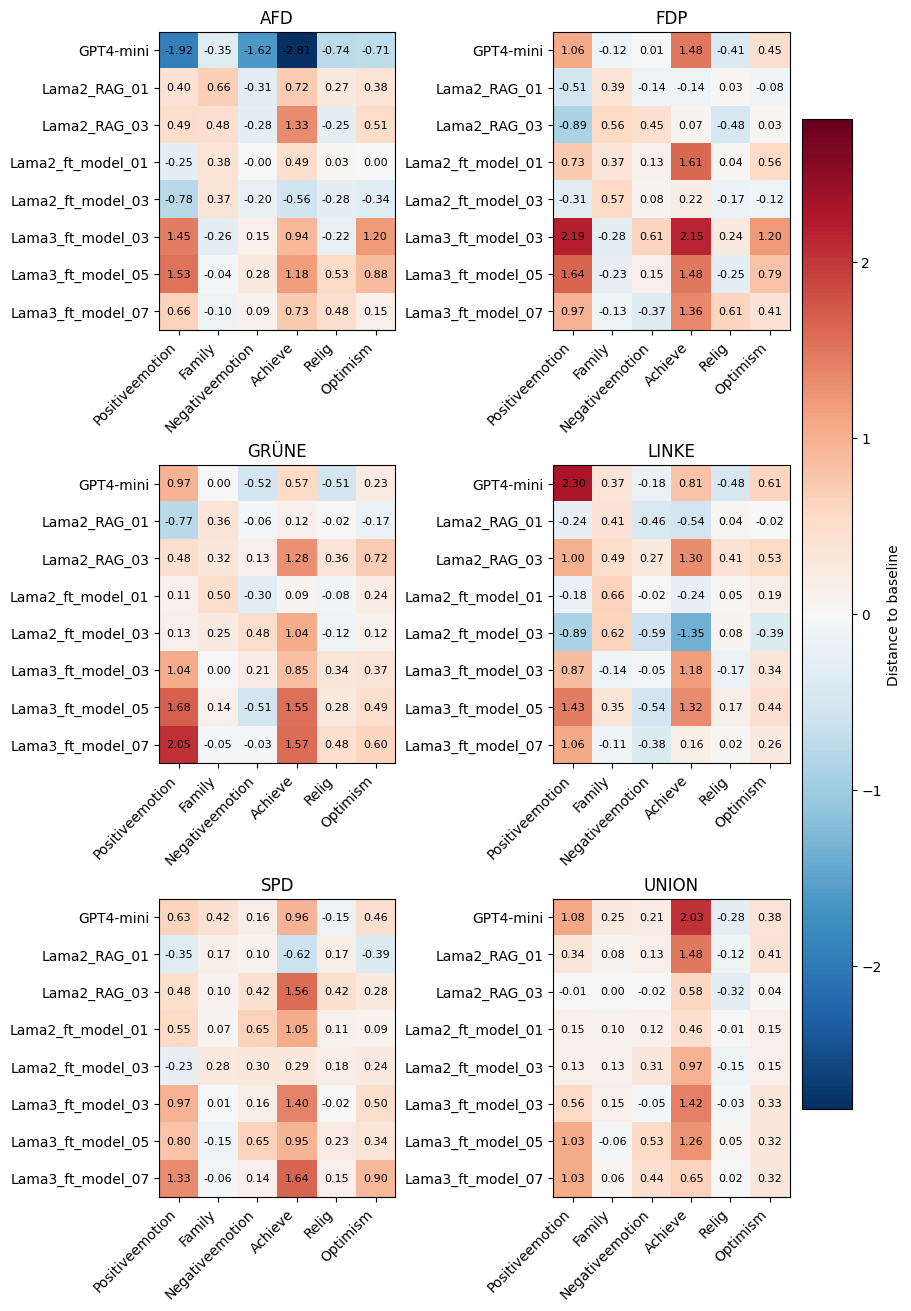

In [93]:
# Calculation of divergence 
delta = df[['party', 'model'] + metrics].merge(base, left_on='party', right_index=True, how='left')
for m in metrics:
    delta[m] = delta[m] - delta[f'{m}_base']
delta = delta[delta['model'] != 'Baseline'].copy()

# Ordering
model_order = delta['model'].dropna().drop_duplicates().tolist()
party_order = ['AFD','FDP','GRÜNE','LINKE','SPD','UNION']  

# Skaling
vmax = np.nanmax(np.abs(delta[metrics].to_numpy()))
norm = colors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
cmap = 'RdBu_r'  # divergend, blau = negativ, rot = positiv

########
# Figure 
fig, axes = plt.subplots(3, 2, figsize=(9, 13), constrained_layout=True)
axes = axes.ravel()

for ax, party in zip(axes, party_order):
    sub = delta.loc[delta['party'] == party, ['model'] + metrics]
    mat = (sub.set_index('model')
               .reindex(model_order)[metrics])
   
    mat = mat[~mat.isna().all(axis=1)]
    if mat.empty:
        ax.axis('off')
        continue

    im = ax.imshow(mat.values, aspect='auto', norm=norm, cmap=cmap)

    ax.set_title(party)
    ax.set_xticks(range(len(metrics)))
    ax.set_xticklabels(metrics, rotation=45, ha='right')
    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels(mat.index)

    
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat.values[i, j]
            if np.isfinite(v):
                ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8)

for k in range(len(party_order), len(axes)):
    axes[k].axis('off')


cbar = fig.colorbar(im, ax=axes.tolist(), shrink=0.85, pad=0.02)
cbar.set_label('Distance to baseline')

# Saving
fig.savefig(outfile_png, dpi=300, bbox_inches='tight')
stem = f"liwc_delta_heatmap_2x3"
fig.savefig(outdir / f"{stem}.png", dpi=300, bbox_inches='tight')
